In [ ]:
# Dados para download
Base_Dados_Nesse_Link = 'https://docs.google.com/spreadsheets/d/1r0_Vs5QX1ef5X1MZCbDg8kcqm-my3rSn/edit?usp=sharing&ouid=108903987275959757465&rtpof=true&sd=true'

print('Dados salvo no Google Driver')
print( Base_Dados_Nesse_Link )

Dados salvo no Google Driver
https://docs.google.com/spreadsheets/d/1r0_Vs5QX1ef5X1MZCbDg8kcqm-my3rSn/edit?usp=sharing&ouid=108903987275959757465&rtpof=true&sd=true


In [ ]:
# Libs necessárias

# Libs para Modelagem e Matrizes
import numpy as np
import pandas as pd

# Libs para Análises gráficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Lib para ignorar avisos
import warnings

# Desabilitando avisos
warnings.filterwarnings('ignore')

In [ ]:
# Lendos os dados
Base_Dados = pd.read_excel('/content/Vase_004 - Magalu - Sem Resolução.xlsx')

# Verificando
Base_Dados.head()

,Data,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
0,2021-01-04,25.580000,24.870001,25.260000,25.200001,25706100,25.181740
1,2021-01-05,25.180000,24.340000,25.100000,24.760000,25431900,24.742058
2,2021-01-06,24.660000,23.420000,24.650000,23.459999,51799000,23.442999
3,2021-01-07,23.850000,22.950001,23.639999,23.160000,42146600,23.143217
4,2021-01-08,24.299999,23.020000,23.190001,23.840000,43988100,23.822723


In [ ]:
Base_Dados.shape

(247, 7)

In [ ]:
Base_Dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Data        247 non-null    datetime64[ns]
 1   Maior       247 non-null    float64       
 2   Menor       247 non-null    float64       
 3   Abertura    247 non-null    float64       
 4   Fechamento  247 non-null    float64       
 5   Volume      247 non-null    int64         
 6   Adj Close   247 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 13.6 KB


In [ ]:
Base_Dados.describe()

,Data,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
count,247,247.000000,247.000000,247.000000,247.000000,2.470000e+02,247.000000
mean,2021-07-02 21:28:25.263158016,18.977530,18.205668,18.629717,18.549555,4.536056e+07,18.541389
min,2021-01-04 00:00:00,6.200000,5.620000,5.710000,5.740000,8.716100e+06,5.740000
25%,2021-04-05 12:00:00,15.010000,14.275000,14.705000,14.555000,2.285200e+07,14.555000
50%,2021-07-02 00:00:00,20.650000,19.930000,20.280001,20.270000,3.130900e+07,20.255312
75%,2021-09-29 12:00:00,22.595000,21.985001,22.375000,22.200001,4.742785e+07,22.183912
max,2021-12-30 00:00:00,27.070000,25.900000,26.250000,26.240000,2.578313e+08,26.220984
std,NaN,5.632712,5.567061,5.602659,5.637050,4.082594e+07,5.631316


In [ ]:
# Series Temporais
Dados = Base_Dados.set_index('Data')

Dados.head()

,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
Data,,,,,,
2021-01-04,25.580000,24.870001,25.260000,25.200001,25706100,25.181740
2021-01-05,25.180000,24.340000,25.100000,24.760000,25431900,24.742058
2021-01-06,24.660000,23.420000,24.650000,23.459999,51799000,23.442999
2021-01-07,23.850000,22.950001,23.639999,23.160000,42146600,23.143217
2021-01-08,24.299999,23.020000,23.190001,23.840000,43988100,23.822723


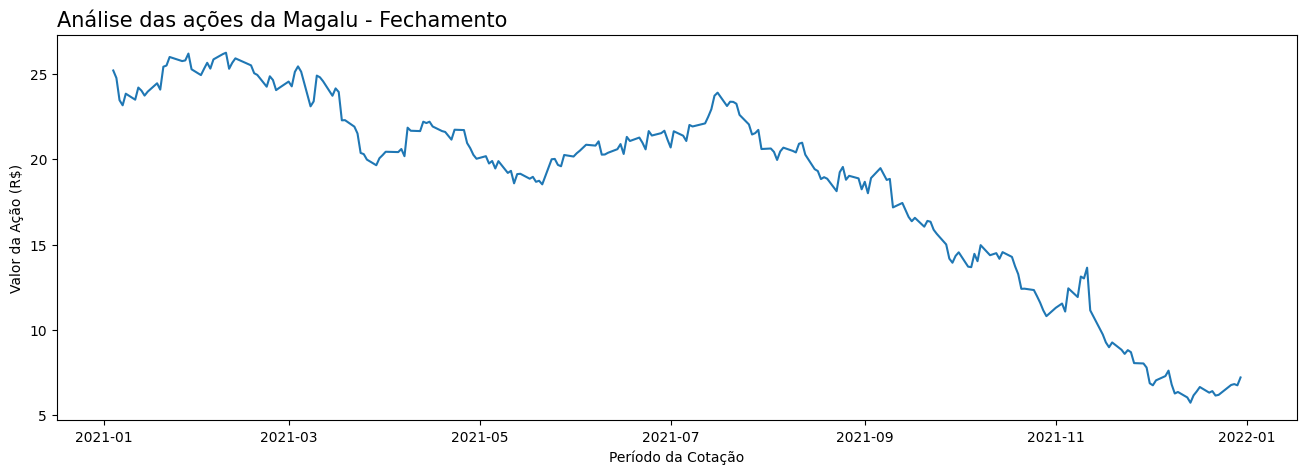

In [ ]:
# plt.style.use('seaborn-darkgrid')
plt.figure( figsize=(16,5))
plt.title('Análise das ações da Magalu - Fechamento', fontsize=15, loc='left')
plt.plot( Dados.index, Dados['Fechamento'])

plt.xlabel('Período da Cotação')
plt.ylabel('Valor da Ação (R$)');

In [ ]:
Dados.tail()

,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
Data,,,,,,
2021-12-23,6.34,5.99,6.22,6.20,97106100,6.20
2021-12-27,6.78,6.23,6.23,6.78,124279800,6.78
2021-12-28,6.96,6.64,6.79,6.83,165573900,6.83
2021-12-29,6.90,6.70,6.84,6.76,79247400,6.76
2021-12-30,7.41,6.77,6.80,7.22,180329400,7.22


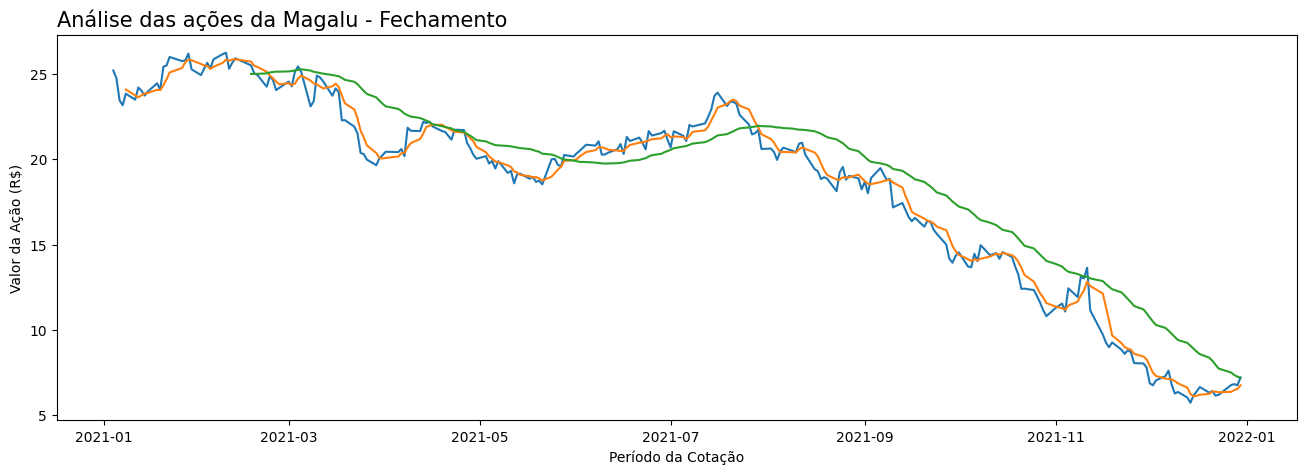

In [ ]:
Media_Movel = Dados['Fechamento'].rolling(5).mean()
Media_Tendencia = Dados['Fechamento'].rolling(30).mean()

# plt.style.use('seaborn-darkgrid')
plt.figure( figsize=(16,5))
plt.title('Análise das ações da Magalu - Fechamento', fontsize=15, loc='left')
plt.plot( Dados.index, Dados['Fechamento'])
plt.plot( Media_Movel.index, Media_Movel)
plt.plot( Media_Tendencia.index, Media_Tendencia)

plt.xlabel('Período da Cotação')
plt.ylabel('Valor da Ação (R$)');

<Axes: xlabel='Fechamento'>

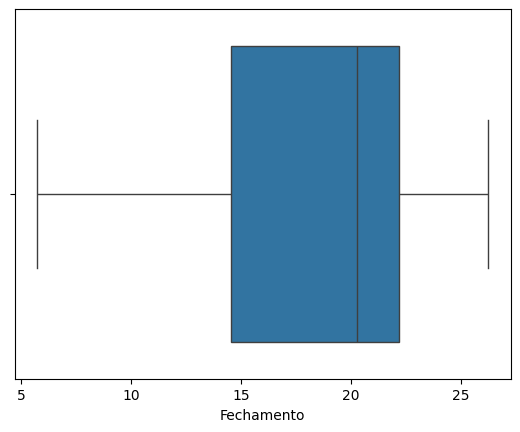

In [ ]:
sns.boxplot( data=Dados, x='Fechamento')

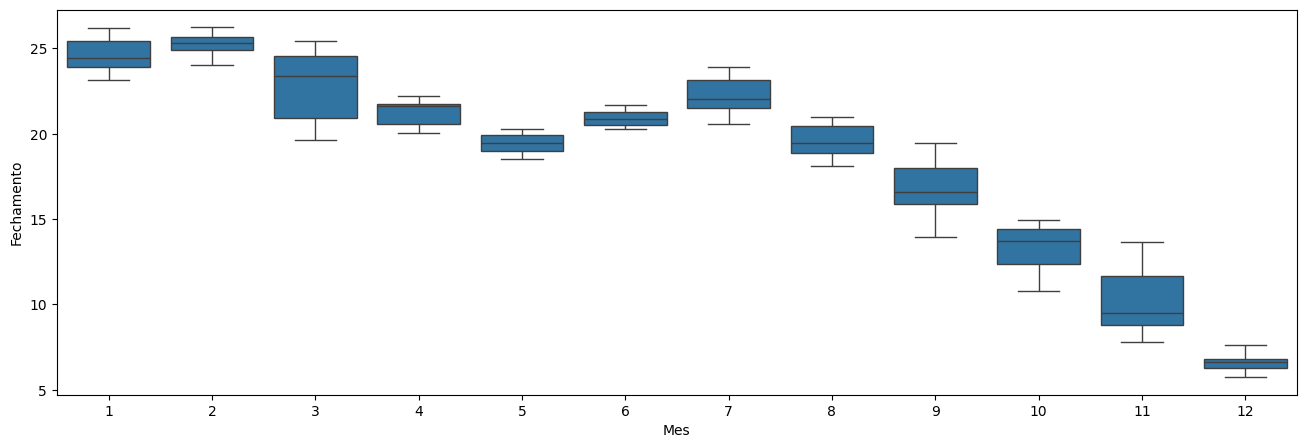

In [ ]:
# Boxplot Mensal

Base_Dados['Mes'] = Base_Dados['Data'].dt.month

plt.figure( figsize=(16,5))
sns.boxplot( data=Base_Dados, x='Mes', y='Fechamento');

In [ ]:
Base_Dados.groupby('Mes').describe()['Fechamento']

,count,mean,min,25%,50%,75%,max,std
Mes,,,,,,,,
1,19.0,24.644737,23.160000,23.900000,24.450001,25.455000,26.190001,0.960280
2,18.0,25.208889,24.049999,24.877501,25.299999,25.650000,26.240000,0.656021
3,23.0,22.855217,19.650000,20.940001,23.389999,24.559999,25.440001,1.976698
4,20.0,21.249000,20.030001,20.560000,21.625000,21.760000,22.200001,0.735297
5,21.0,19.430476,18.530001,18.969999,19.459999,19.900000,20.250000,0.564973
6,21.0,20.898095,20.270000,20.500000,20.889999,21.270000,21.670000,0.463116
7,21.0,22.232857,20.600000,21.530001,22.040001,23.120001,23.900000,0.977574
8,22.0,19.656818,18.129999,18.897500,19.485000,20.452499,20.969999,0.885827
9,21.0,16.746191,13.940000,15.870000,16.570000,18.010000,19.480000,1.628581


In [ ]:
#
Grafico = go.Figure(
    data=[
        go.Candlestick(
            x=Dados.index,
            open = Dados['Abertura'],
            high = Dados['Maior'],
            low = Dados['Menor'],
            close = Dados['Fechamento']
        )
    ]
)
Grafico.update_layout( xaxis_rangeslider_visible=False )

Grafico.show()